#**PHASE 2**

#STEP-1 FAERS Data

In [1]:
import requests
import pandas as pd

# API endpoint
url = "https://api.fda.gov/drug/event.json"

params = {
    "search": 'patient.drug.medicinalproduct:"SEMAGLUTIDE"',
    "count": "patient.reaction.reactionmeddrapt.exact",
    "limit": 100
}

response = requests.get(url, params=params)
data = response.json()

# Convert to dataframe
results = data['results']
df = pd.DataFrame(results)

df.columns = ['Adverse_Event', 'Count']

df.head()

,Adverse_Event,Count
0,NAUSEA,862
1,VOMITING,750
2,DIARRHOEA,537
3,OFF LABEL USE,362
4,FATIGUE,360


#STEP-2 Clean the Data

In [2]:
# Convert event names to lowercase (for matching later)
df['Adverse_Event'] = df['Adverse_Event'].str.lower()

# Sort by count
df = df.sort_values(by='Count', ascending=False)

df.head(20)

,Adverse_Event,Count
0,nausea,862
1,vomiting,750
2,diarrhoea,537
3,off label use,362
4,fatigue,360
5,weight decreased,360
6,dyspnoea,353
7,drug ineffective,340
8,dizziness,288
9,headache,276


#STEP-3 Keep Only Relevant Events (Match with RCT)

In [3]:
rct_events = [
    "nausea", "vomiting", "diarrhea", "constipation",
    "abdominal pain", "dyspepsia", "hypoglycemia",
    "pancreatitis", "gallbladder disease",
    "fatigue", "headache", "dizziness"
]

filtered_df = df[df['Adverse_Event'].isin(rct_events)]

filtered_df

,Adverse_Event,Count
0,nausea,862
1,vomiting,750
4,fatigue,360
8,dizziness,288
9,headache,276
12,abdominal pain,232
13,constipation,231
31,pancreatitis,147
89,dyspepsia,76


improve matching

In [4]:
df['Adverse_Event'] = df['Adverse_Event'].replace({
    "diarrhoea": "diarrhea",
    "abdominal pain upper": "abdominal pain",
    "cholelithiasis": "gallbladder disease"
})

#STEP-4 Save the Dataset

In [5]:
filtered_df.to_csv("semaglutide_faers_filtered.csv", index=False)

#STEP-5 Visualization

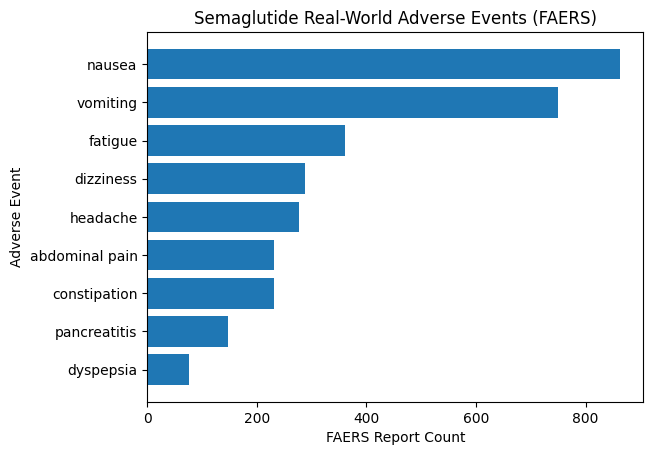

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(filtered_df['Adverse_Event'], filtered_df['Count'])
plt.xlabel("FAERS Report Count")
plt.ylabel("Adverse Event")
plt.title("Semaglutide Real-World Adverse Events (FAERS)")
plt.gca().invert_yaxis()
plt.show()

#**PHASE 3**

semaglutide raw data to csv

In [7]:
import pandas as pd

data = {
    "adverse_event": ["nausea","vomiting","diarrhea","constipation","abdominal pain",
                      "dyspepsia","gastroesophageal reflux disease","hypoglycemia",
                      "fatigue","headache","dizziness","decreased appetite",
                      "pancreatitis","gallbladder disease","acute kidney injury","retinopathy"],
    "semaglutide_rate": [44,24,30,24,10,7,5,6,8,9,5,12,1,2,1,7],
    "placebo_rate": [17,6,16,11,4,3,2,3,5,6,3,4,0,1,0.5,6]
}

df = pd.DataFrame(data)
df.to_csv("semaglutide_rct_data.csv", index=False)

print("File created!")

File created!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: LOAD TWO DATASETS

In [9]:
# 1. semaglutide_rct_data.csv
# 2. semaglutide_faers_filtered.csv

rct_df = pd.read_csv("semaglutide_rct_data.csv")
faers_df = pd.read_csv("semaglutide_faers_filtered.csv")

print("RCT Data Preview:")
print(rct_df.head())

print("\nFAERS Data Preview:")
print(faers_df.head())


RCT Data Preview:
    adverse_event  semaglutide_rate  placebo_rate
0          nausea                44          17.0
1        vomiting                24           6.0
2        diarrhea                30          16.0
3    constipation                24          11.0
4  abdominal pain                10           4.0

FAERS Data Preview:
  Adverse_Event  Count
0        nausea    862
1      vomiting    750
2       fatigue    360
3     dizziness    288
4      headache    276


# STEP 2: CLEAN COLUMN NAMES

In [10]:
rct_df.columns = rct_df.columns.str.strip().str.lower()
faers_df.columns = faers_df.columns.str.strip().str.lower()

# Expected RCT columns:
# adverse_event, semaglutide_rate, placebo_rate
# Expected FAERS columns:
# adverse_event, count

print("\nRCT Columns:", rct_df.columns.tolist())
print("FAERS Columns:", faers_df.columns.tolist())



RCT Columns: ['adverse_event', 'semaglutide_rate', 'placebo_rate']
FAERS Columns: ['adverse_event', 'count']


# STEP 3: STANDARDIZE ADVERSE EVENT NAMES

In [11]:
rct_df["adverse_event"] = rct_df["adverse_event"].str.strip().str.lower()
faers_df["adverse_event"] = faers_df["adverse_event"].str.strip().str.lower()

# Optional mapping to make names match better
event_mapping = {
    "diarrhoea": "diarrhea",
    "abdominal pain upper": "abdominal pain",
    "cholelithiasis": "gallbladder disease",
    "gastrooesophageal reflux disease": "gastroesophageal reflux disease"
}

rct_df["adverse_event"] = rct_df["adverse_event"].replace(event_mapping)
faers_df["adverse_event"] = faers_df["adverse_event"].replace(event_mapping)


# STEP 4: CONVERT PERCENTAGES TO PROPORTIONS

In [12]:
#  semaglutide_rate and placebo_rate are percentages are 44, 17
# converted them to proportions like 0.44, 0.17

rct_df["trial_rate"] = rct_df["semaglutide_rate"] / 100
rct_df["placebo_rate_prop"] = rct_df["placebo_rate"] / 100

# Optional additional metric: risk difference
rct_df["risk_difference"] = rct_df["trial_rate"] - rct_df["placebo_rate_prop"]



# STEP 5: NORMALIZE FAERS COUNTS

In [13]:
total_faers_reports = faers_df["count"].sum()
faers_df["faers_rate"] = faers_df["count"] / total_faers_reports


# STEP 6: MERGE RCT + FAERS DATA

In [14]:
merged_df = pd.merge(
    rct_df,
    faers_df,
    on="adverse_event",
    how="inner"
)

print("\nMerged Data:")
print(merged_df.head())



Merged Data:
    adverse_event  semaglutide_rate  placebo_rate  trial_rate  \
0          nausea                44          17.0        0.44   
1        vomiting                24           6.0        0.24   
2    constipation                24          11.0        0.24   
3  abdominal pain                10           4.0        0.10   
4       dyspepsia                 7           3.0        0.07   

   placebo_rate_prop  risk_difference  count  faers_rate  
0               0.17             0.27    862    0.267536  
1               0.06             0.18    750    0.232775  
2               0.11             0.13    231    0.071695  
3               0.04             0.06    232    0.072005  
4               0.03             0.04     76    0.023588  


# STEP 7: CALCULATE DIVERGENCE SCORE

In [15]:
# Simple divergence score:
# FAERS proportion - trial proportion

merged_df["divergence_score"] = merged_df["faers_rate"] - merged_df["trial_rate"]

# Absolute divergence can also be useful
merged_df["absolute_divergence"] = merged_df["divergence_score"].abs()

# Sort by highest absolute divergence
merged_df = merged_df.sort_values(by="absolute_divergence", ascending=False)

print("\nFinal Divergence Table:")
print(merged_df[
    [
        "adverse_event",
        "trial_rate",
        "placebo_rate_prop",
        "risk_difference",
        "count",
        "faers_rate",
        "divergence_score",
        "absolute_divergence"
    ]
])



Final Divergence Table:
    adverse_event  trial_rate  placebo_rate_prop  risk_difference  count  \
0          nausea        0.44               0.17             0.27    862   
2    constipation        0.24               0.11             0.13    231   
4       dyspepsia        0.07               0.03             0.04     76   
7       dizziness        0.05               0.03             0.02    288   
8    pancreatitis        0.01               0.00             0.01    147   
5         fatigue        0.08               0.05             0.03    360   
3  abdominal pain        0.10               0.04             0.06    232   
1        vomiting        0.24               0.06             0.18    750   
6        headache        0.09               0.06             0.03    276   

   faers_rate  divergence_score  absolute_divergence  
0    0.267536         -0.172464             0.172464  
2    0.071695         -0.168305             0.168305  
4    0.023588         -0.046412             0.046

# STEP 8: INTERPRETATION LABELS

In [16]:
def interpret_divergence(score):
    if score > 0:
        return "Higher in FAERS"
    elif score < 0:
        return "Higher in Clinical Trials"
    else:
        return "Similar"

merged_df["interpretation"] = merged_df["divergence_score"].apply(interpret_divergence)

print("\nInterpretation:")
print(merged_df[["adverse_event", "divergence_score", "interpretation"]])



Interpretation:
    adverse_event  divergence_score             interpretation
0          nausea         -0.172464  Higher in Clinical Trials
2    constipation         -0.168305  Higher in Clinical Trials
4       dyspepsia         -0.046412  Higher in Clinical Trials
7       dizziness          0.039385            Higher in FAERS
8    pancreatitis          0.035624            Higher in FAERS
5         fatigue          0.031732            Higher in FAERS
3  abdominal pain         -0.027995  Higher in Clinical Trials
1        vomiting         -0.007225  Higher in Clinical Trials
6        headache         -0.004339  Higher in Clinical Trials


# STEP 9: SAVE FINAL RESULTS

In [17]:
merged_df.to_csv("semaglutide_phase3_divergence_results.csv", index=False)
print("\nSaved: semaglutide_phase3_divergence_results.csv")



Saved: semaglutide_phase3_divergence_results.csv


# STEP 10: BAR CHART OF DIVERGENCE

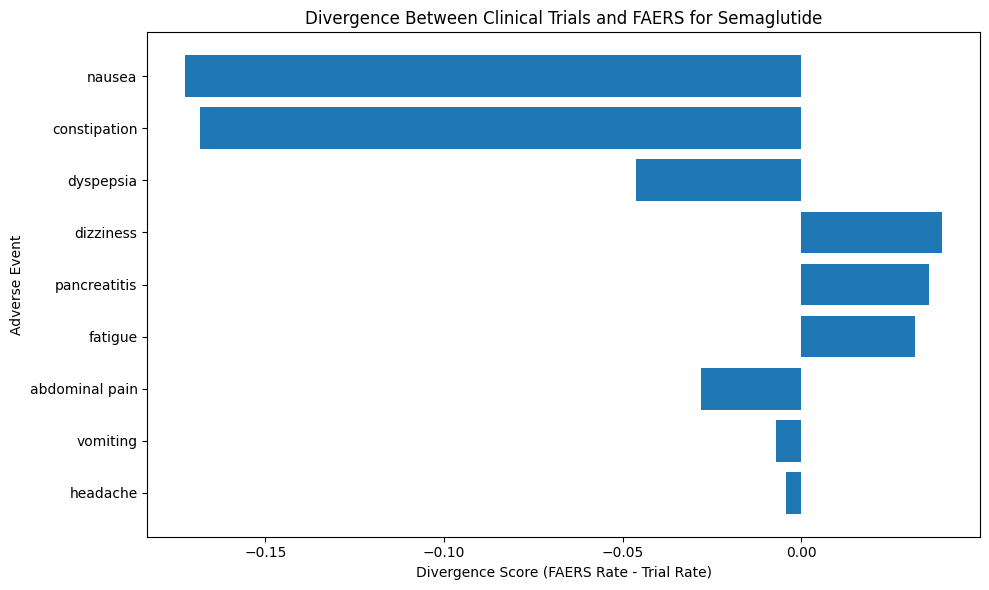

In [18]:
top_plot_df = merged_df.sort_values(by="absolute_divergence", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_plot_df["adverse_event"], top_plot_df["divergence_score"])
plt.xlabel("Divergence Score (FAERS Rate - Trial Rate)")
plt.ylabel("Adverse Event")
plt.title("Divergence Between Clinical Trials and FAERS for Semaglutide")
plt.tight_layout()
plt.show()

# STEP 11: SCATTER PLOT

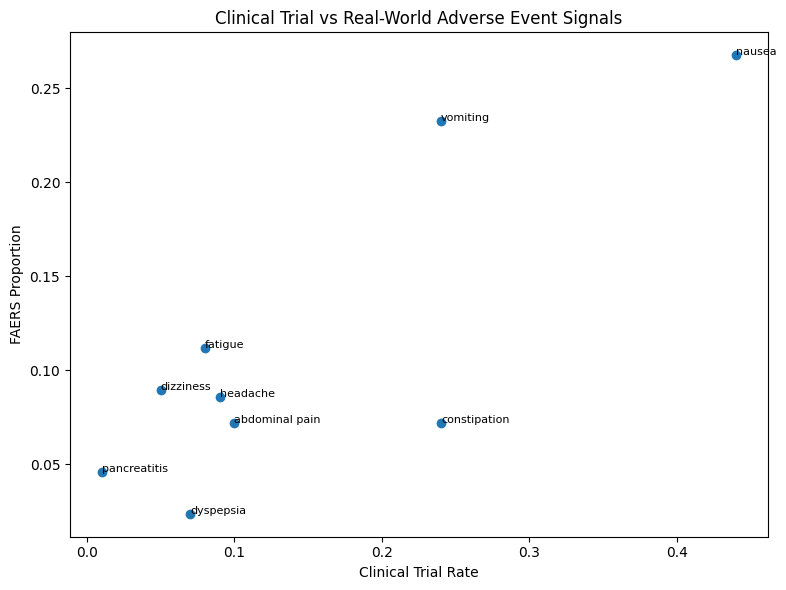

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(merged_df["trial_rate"], merged_df["faers_rate"])

for _, row in merged_df.iterrows():
    plt.text(row["trial_rate"], row["faers_rate"], row["adverse_event"], fontsize=8)

plt.xlabel("Clinical Trial Rate")
plt.ylabel("FAERS Proportion")
plt.title("Clinical Trial vs Real-World Adverse Event Signals")
plt.tight_layout()
plt.show()

# STEP 12: OPTIONAL HEATMAP-LIKE TABLE VIEW

In [20]:
heatmap_df = merged_df[
    [
        "adverse_event",
        "trial_rate",
        "placebo_rate_prop",
        "risk_difference",
        "faers_rate",
        "divergence_score"
    ]
].copy()

print("\nHeatmap-style Summary Table:")
print(heatmap_df)


Heatmap-style Summary Table:
    adverse_event  trial_rate  placebo_rate_prop  risk_difference  faers_rate  \
0          nausea        0.44               0.17             0.27    0.267536   
2    constipation        0.24               0.11             0.13    0.071695   
4       dyspepsia        0.07               0.03             0.04    0.023588   
7       dizziness        0.05               0.03             0.02    0.089385   
8    pancreatitis        0.01               0.00             0.01    0.045624   
5         fatigue        0.08               0.05             0.03    0.111732   
3  abdominal pain        0.10               0.04             0.06    0.072005   
1        vomiting        0.24               0.06             0.18    0.232775   
6        headache        0.09               0.06             0.03    0.085661   

   divergence_score  
0         -0.172464  
2         -0.168305  
4         -0.046412  
7          0.039385  
8          0.035624  
5          0.031732  
3    

#Phase 4 — Visualization

1. Bar Chart — Divergence

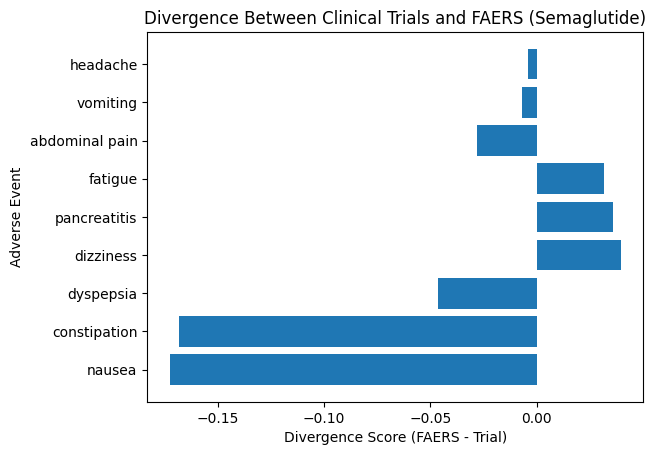

In [21]:
import matplotlib.pyplot as plt

# Sort for better visualization
plot_df = merged_df.sort_values(by="absolute_divergence", ascending=True)

plt.figure()
plt.barh(plot_df["adverse_event"], plot_df["divergence_score"])
plt.xlabel("Divergence Score (FAERS - Trial)")
plt.ylabel("Adverse Event")
plt.title("Divergence Between Clinical Trials and FAERS (Semaglutide)")
plt.gca().invert_yaxis()
plt.show()

# Interpretation:
Negative values (left side):
Nausea, constipation, dyspepsia → more common in clinical trials

Positive values (right side):
Dizziness, pancreatitis, fatigue → more common in real-world (FAERS)

Near zero:
Headache, vomiting → similar in both

2. Scatter Plot — Trial vs Real World

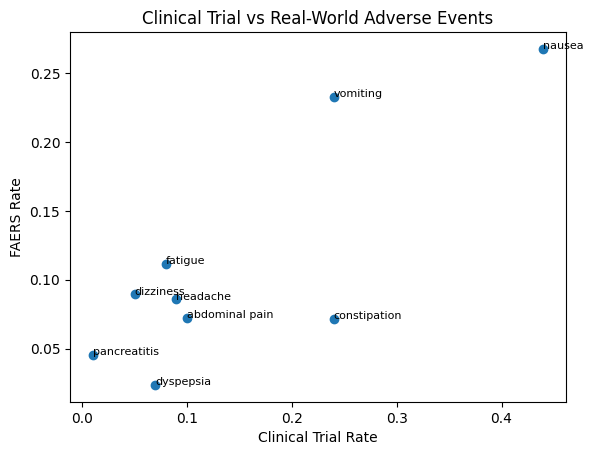

In [22]:
plt.figure()

plt.scatter(merged_df["trial_rate"], merged_df["faers_rate"])

for i, row in merged_df.iterrows():
    plt.text(row["trial_rate"], row["faers_rate"], row["adverse_event"], fontsize=8)

plt.xlabel("Clinical Trial Rate")
plt.ylabel("FAERS Rate")
plt.title("Clinical Trial vs Real-World Adverse Events")
plt.show()

# Interpretation:
Points show trial rate (x-axis) vs FAERS rate (y-axis)

If both are similar → point lies near a diagonal trend

Key Insights:
Nausea, vomiting: high in both → consistent reporting

Constipation: high in trials but lower in FAERS → trial-heavy

Fatigue, dizziness: relatively higher in FAERS → real-world signal

Pancreatitis: low in trials but appears in FAERS → important safety signal

3. Top FAERS Events Chart


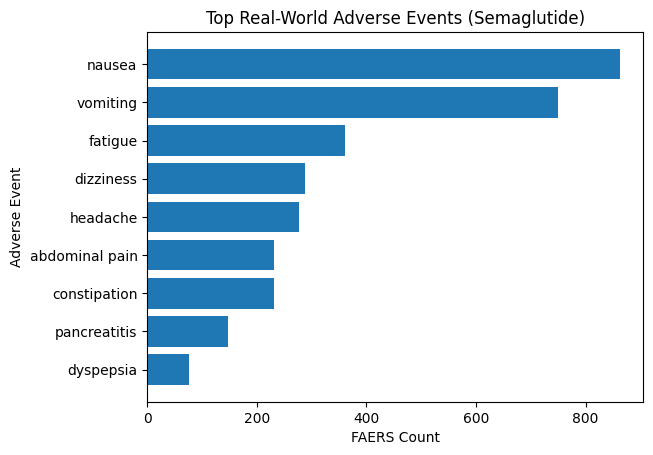

In [23]:
top_faers = faers_df.sort_values(by="count", ascending=False).head(10)

plt.figure()
plt.barh(top_faers["adverse_event"], top_faers["count"])
plt.xlabel("FAERS Count")
plt.ylabel("Adverse Event")
plt.title("Top Real-World Adverse Events (Semaglutide)")
plt.gca().invert_yaxis()
plt.show()

# Interpretation:
Most common real-world adverse events:
Nausea > Vomiting > Fatigue > Dizziness

Moderate:
Headache, abdominal pain, constipation

Less common but important:
Pancreatitis, dyspepsia

Gastrointestinal issues (nausea, vomiting) dominate in real-world data, while serious events like pancreatitis, though less frequent, are clinically important safety signals.

4. Heatmap-style Table

In [24]:
print(merged_df[[
    "adverse_event",
    "trial_rate",
    "faers_rate",
    "divergence_score"
]])

    adverse_event  trial_rate  faers_rate  divergence_score
0          nausea        0.44    0.267536         -0.172464
2    constipation        0.24    0.071695         -0.168305
4       dyspepsia        0.07    0.023588         -0.046412
7       dizziness        0.05    0.089385          0.039385
8    pancreatitis        0.01    0.045624          0.035624
5         fatigue        0.08    0.111732          0.031732
3  abdominal pain        0.10    0.072005         -0.027995
1        vomiting        0.24    0.232775         -0.007225
6        headache        0.09    0.085661         -0.004339


# Interpretation
Highest trial rates: nausea (0.44), constipation (0.24)

Higher in FAERS: dizziness, pancreatitis, fatigue

Negative divergence: nausea, constipation → more in trials

Positive divergence: pancreatitis, dizziness → more in real-world

Near zero: vomiting, headache → similar in both

Some side effects are overrepresented in trials, while real-world data reveals additional safety signals, especially pancreatitis and dizziness.
